# ISIS `photomet` (Hapke) as a hillshade replacement -- feasibility prototype

`image_generation.ipynb`'s hillshade-based ortho basemap (`dem_ortho_result.ortho`, Phase 3) is
shaded with a plain Lambertian `matplotlib.colors.LightSource.hillshade` blend
(`lunaserv.shade_ortho`) -- real-sun-direction-lit, but not a real photometric model (no
opposition surge, no macroscopic-roughness term, no real lunar reflectance behavior). This
notebook evaluates swapping that for ISIS's own `photomet` application using a real Hapke
bidirectional reflectance function (`PHTNAME=HAPKEHEN`), added as a new `hapke=True` flag on
`lunaserv.fetch_dem_and_ortho`/`despeckle_and_shade_ortho` (see `hapke_shade_ortho`'s docstring)
rather than replacing the existing Lambertian path.

The tricky part evaluated here: `photomet`'s automatic angle sources (`ANGLESOURCE=ELLIPSOID`/
`DEM`) need a real ISIS camera model embedded in the cube (via `spiceinit`) to derive
incidence/emission/phase angles from -- but this ortho is a flat, map-projected mosaic with no
ISIS camera model at all (real or synthetic). The fix used here: `ANGLESOURCE=BACKPLANE`, feeding
`photomet` angle rasters computed directly in Python (`lunaserv._terrain_photometric_angles`,
from the DEM's own surface normals and the same real SPICE sun direction `shade_ortho` already
uses) -- `photomet` only does the Hapke math, not the geometry. This sidesteps the "no camera
model" problem entirely, at the cost of only being valid for a nadir/orthographic view (emission
angle from local-normal-vs-straight-up, not a real perspective camera) -- fine for this basemap,
not yet a general answer for relighting the *synthetic camera's own* perspective render.

Minimum setup to get there: reuses `image_generation.ipynb`'s Phase 1-2 exactly (same manifest,
same `TrnTestDataSet`), but skips `dataset.populate()` entirely -- `entry.camera` is enough to
fetch a DEM/ortho pair, and this notebook doesn't need the `sat_sim` render or the ISIS WAC crop
either phase would otherwise generate. Displays the existing Lambertian ortho blinked against a
freshly-fetched Hapke-shaded ortho of the same footprint, via the same `plot_overlay_toggle`
blink-comparator Phase 5B/6B use -- here comparing the two shading modes directly against each
other (both share the exact same pixel grid, being the same DEM/ortho fetch with only the final
shading step differing) rather than comparing a render against a basemap.

In [1]:
import trntest
from trntest import lunaserv, plotting

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera

print(f"EDR product: {entry.edr_product}")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

EDR product: M1327210646CE
Ground footprint center (lon, lat): (np.float64(169.57576859858), np.float64(38.772670465555))


## Fetch both shading variants

`entry.dem_ortho_result` is the existing Lambertian-shaded basemap (resumed from disk if
`image_generation.ipynb` already generated it for this manifest entry, else fetched fresh here).
`lunaserv.fetch_dem_and_ortho(..., hapke=True)` fetches the same DEM/ortho pair again -- cheap,
Lunaserv/Astropedia fetches are independently cached by `cache.py` -- but shades it with
`photomet`'s Hapke model instead, writing to its own `ortho_shaded_hapke.tif` so it doesn't
collide with the Lambertian file.

In [2]:
dem_ortho_lambertian = entry.dem_ortho_result
dem_ortho_hapke = lunaserv.fetch_dem_and_ortho(camera, entry.per_image_config, hapke=True)

print("Lambertian ortho:", dem_ortho_lambertian.ortho)
print("Hapke ortho:     ", dem_ortho_hapke.ortho)

ROI center (lon,lat deg): (np.float64(169.57576859858), np.float64(38.772670465555)), bbox (local m): (-126222.02784515591, -126552.58747697482, 138258.1387844415, 139801.45990725502)
ROI size 2645x2664 px (~100.0 m/px)


Lambertian ortho: /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded.tif
Hapke ortho:      /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke.tif


## Blink comparison

Both orthos share the exact same real georeferencing/pixel grid (same camera footprint, same DEM,
only the final shading step differs), so this is a direct visual read of what the Hapke model
changes relative to the current Lambertian hillshade -- opposition-surge brightening near the
sub-solar point, a different incidence-angle falloff, etc. -- not a geo-registration check like
Phase 5B/6B's own use of this same blink-comparator.


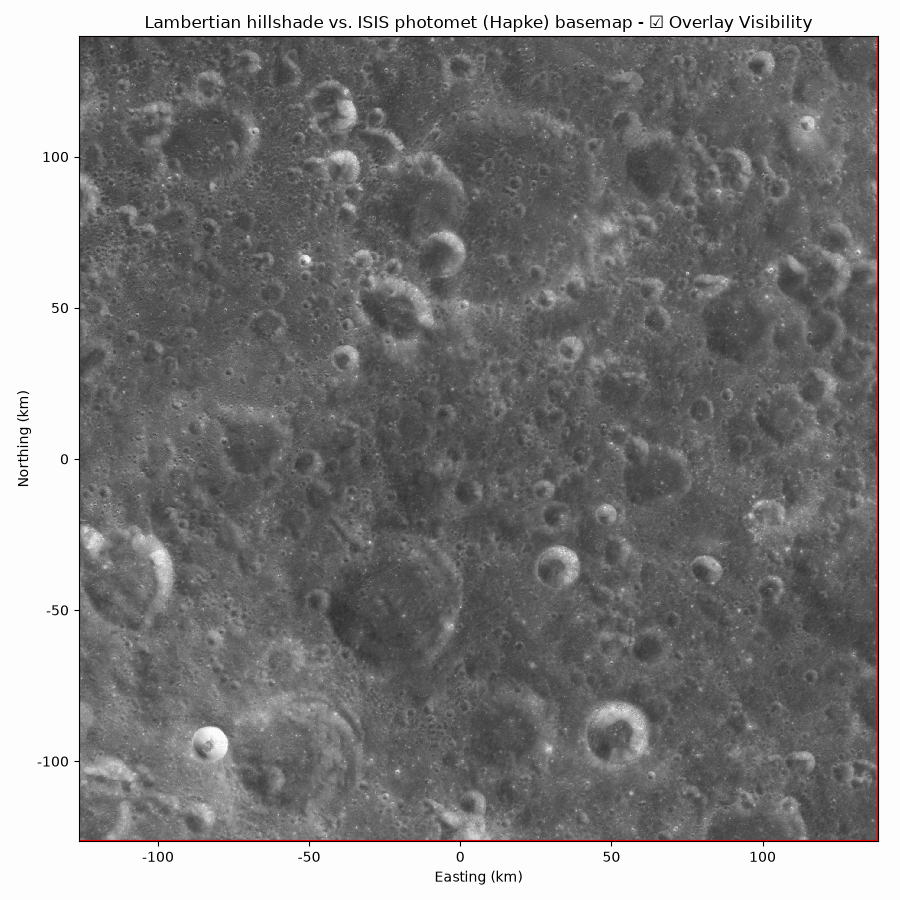

In [3]:
plotting.plot_overlay_toggle(
    dem_ortho_lambertian.ortho,
    dem_ortho_hapke.ortho,
    title="Lambertian hillshade vs. ISIS photomet (Hapke) basemap",
)